# Why Direct PennyLane Training Is Infeasible — Time and Memory Cost

This notebook computes, from the project's own real numbers (config files, actual PPO run, and the ansatz definition), why training the RL scheduler directly against the PennyLane statevector simulator is infeasible on both **time** and **memory** axes — which is why a fast calibrated surrogate is used for RL training instead.

Running the whole notebook (`Run All`) regenerates the exact same numbers and charts below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


## 1. Time cost: extrapolated PennyLane training vs. the calibrated surrogate

- `13 min/episode` at n = 4 qubits — stated on the project's own slide.
- `600 episodes` — the number of episodes the project's own PPO run actually needed to reach reasonable convergence (`outputs/rl_results/simulate/ppo_20260708_012328/summary.json`, return improving from -5.03 to -0.26).

This is a conservative estimate: the real 600-episode run was at n = 6 with max depth 16 (more expensive per circuit than the n = 4 case the 13-minute figure came from).

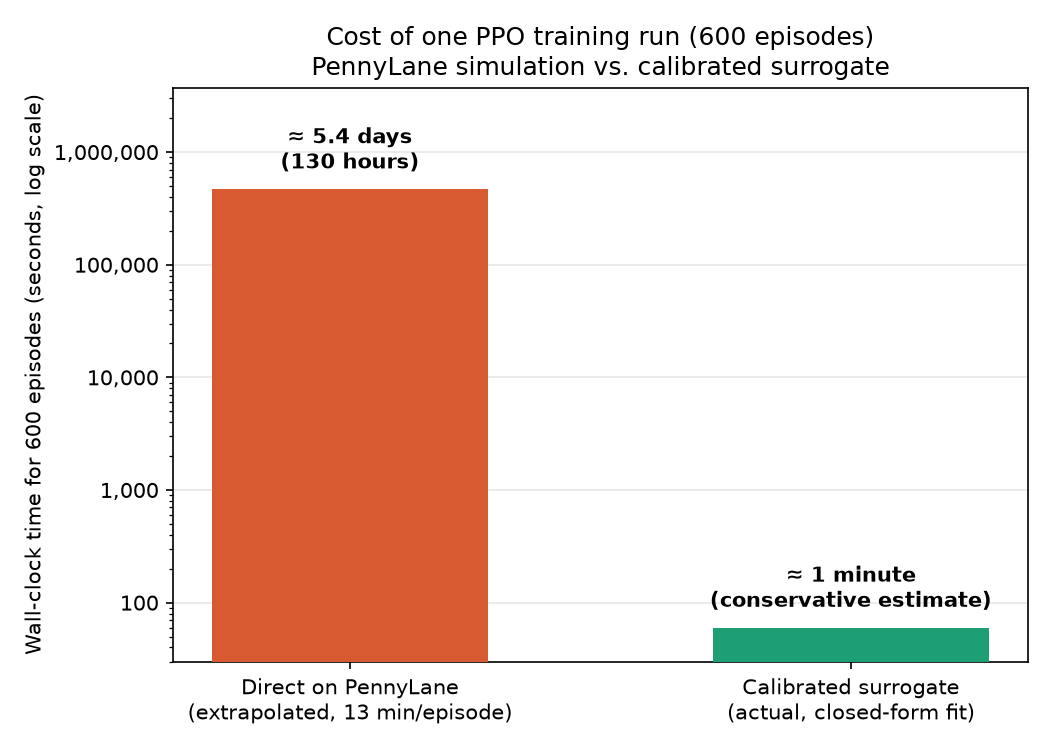

In [2]:
episodes = 600
min_per_episode_pennylane = 13
pennylane_seconds = episodes * min_per_episode_pennylane * 60
surrogate_seconds = 60  # conservative estimate: closed-form fit, no circuit simulation

labels = ["Direct on PennyLane\n(extrapolated, 13 min/episode)", "Calibrated surrogate\n(actual, closed-form fit)"]
values = [pennylane_seconds, surrogate_seconds]
colors = ["#D85A30", "#1D9E75"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.55, zorder=3)
ax.set_yscale("log")
ax.set_ylim(30, pennylane_seconds * 8)
ax.set_ylabel("Wall-clock time for 600 episodes (seconds, log scale)")
ax.set_title(f"Cost of one PPO training run ({episodes} episodes)\nPennyLane simulation vs. calibrated surrogate")

notes = ["\u2248 5.4 days\n(130 hours)", "\u2248 1 minute\n(conservative estimate)"]
for rect, val, note in zip(bars, values, notes):
    ax.annotate(note, (rect.get_x() + rect.get_width() / 2, val),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.grid(True, axis="y", alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()


## 2. Memory cost: vectorizing the gradient batch to fix the time problem

Parameter-shift needs 2 circuit evaluations per parameter. Running them **sequentially** (reusing memory) is what produces the 13-minute-per-episode figure above — slow, but cheap on RAM. Running them **vectorized** (the obvious fix for the time problem) instead explodes memory:

$$\text{RAM} = 2 \times (3 \times n \times L) \times \text{batch} \times 2^n \times 16\text{ bytes}$$

using the project's own real numbers: `batch_size = 16` (`configs/adaptive_alqnn_template.yaml`), `L = 16` (the deepest depth tested in every sweep table), and 3 rotation parameters per qubit per layer (Z-Y-Z decomposition).

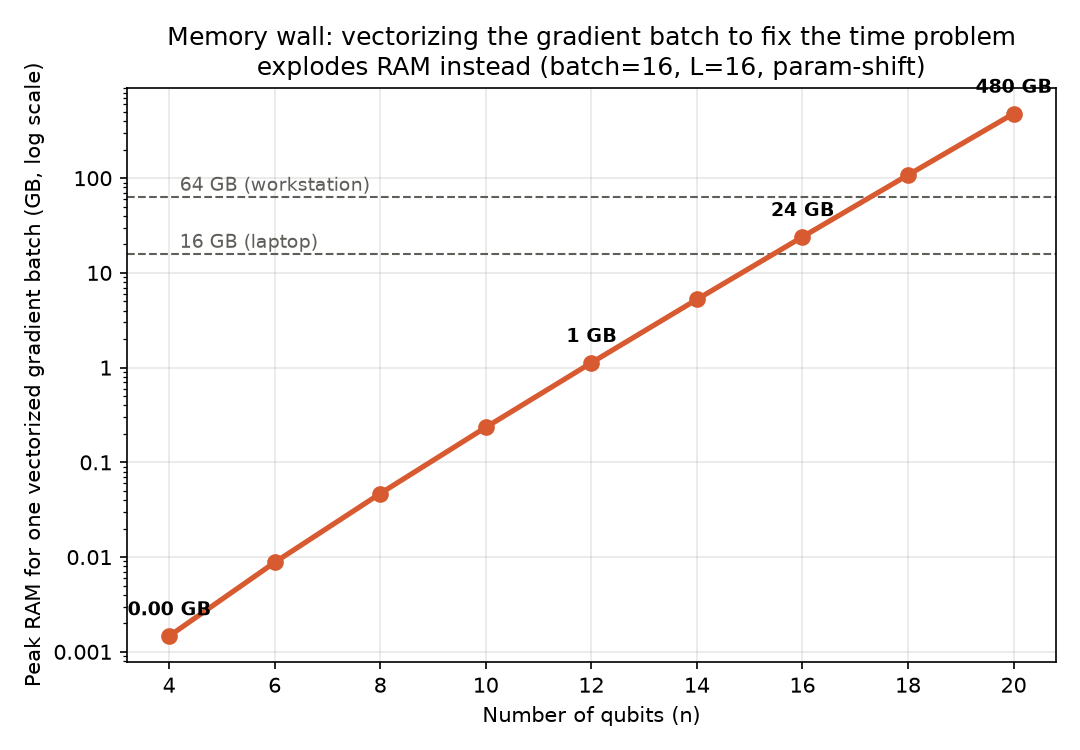

In [3]:
BATCH = 16
PARAMS_PER_QUBIT_PER_LAYER = 3
L = 16
BYTES_PER_AMPLITUDE = 16  # complex128

n_values = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20])
n_params = PARAMS_PER_QUBIT_PER_LAYER * n_values * L
statevector_bytes = (2.0 ** n_values) * BYTES_PER_AMPLITUDE
ram_bytes = 2 * n_params * BATCH * statevector_bytes
ram_gb = ram_bytes / (1024 ** 3)

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(n_values, ram_gb, color="#D85A30", marker="o", linewidth=2.5, markersize=7, zorder=3)
ax.set_yscale("log")
ax.set_xlabel("Number of qubits (n)")
ax.set_ylabel("Peak RAM for one vectorized gradient batch (GB, log scale)")
ax.set_title("Memory wall: vectorizing the gradient batch to fix the time problem\nexplodes RAM instead (batch=16, L=16, param-shift)")

for ref_gb, ref_label in [(16, "16 GB (laptop)"), (64, "64 GB (workstation)")]:
    ax.axhline(ref_gb, color="#5F5E5A", linestyle="--", linewidth=1)
    ax.text(4.2, ref_gb * 1.15, ref_label, fontsize=9, color="#5F5E5A")

for x, y in zip(n_values, ram_gb):
    if x in (4, 12, 16, 20):
        ax.annotate(f"{y:,.2f} GB" if y < 1 else f"{y:,.0f} GB",
                    (x, y), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(n_values)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.4g}"))
ax.grid(True, alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()


In [4]:
for x, y in zip(n_values, ram_gb):
    print(f"n={x:>2}: {y:>10,.4f} GB")


n= 4:     0.0015 GB
n= 6:     0.0088 GB
n= 8:     0.0469 GB
n=10:     0.2344 GB
n=12:     1.1250 GB
n=14:     5.2500 GB
n=16:    24.0000 GB
n=18:   108.0000 GB
n=20:   480.0000 GB


## Takeaway

Whichever way parameter-shift is executed, direct PennyLane training hits a wall:
- **Sequential** execution -> low RAM, but time explodes (~5.4 days per training run, extrapolated).
- **Vectorized** execution -> time improves, but RAM explodes (~480 GB at n = 20, the project's own heavy-BP-regime scope).

The calibrated surrogate (a closed-form fit with ~6 scalar parameters, `outputs/surrogate/*/surrogate_fit.json`) avoids both walls simultaneously, because its cost does not depend on the statevector dimension at all.

### Data source
- `outputs/rl_results/simulate/ppo_20260708_012328/summary.json` — real 600-episode PPO run.
- `configs/adaptive_alqnn_template.yaml` — `batch_size: 16`.
- Ansatz: Z-Y-Z decomposition, 3 rotation parameters per qubit per layer.